# Trabajo Nº1 – Clasificación de Perros y Gatos con CNN y Transfer Learning

Este notebook sirve como plantilla mínima para que puedas comenzar a construir tus propias CNN y aplicar Transfer Learning.  
Incluye:
- Configuración básica e imports.
- Carga de imágenes desde carpetas (`Cats_Dogs/cat` y `Cats_Dogs/dog`) y redimensionado a tamaño fijo.
- Celda final para generar el `.csv` de predicciones con el formato requerido.

Indicaciones:
- En la entrega se proporciona `Cats_Dogs.zip` con 1000 imágenes por clase (carpetas `cat` y `dog`).  
- Descomprime el zip en el mismo directorio del notebook antes de ejecutar.
- Tú debes definir y entrenar tu modelo (CNN propia y un modelo de Transfer Learning).  
- Al final, genera `predicciones_cats_dogs.csv` con el formato especificado.

In [5]:
# Añade aquí los import que utilices en tu código
import os
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.20.0


## Carga de Imágenes

Se cargan exactamente **1000 imágenes de cada clase** desde la carpeta `Cats_Dogs`, asumiendo esta estructura:

```text
Cats_Dogs/
├─ cat/
│  ├─ 0.jpg
│  ├─ ...
├─ dog/
│  ├─ 0.jpg
│  ├─ ...
```

Preprocesamiento:
- Redimensionado a `224×224` píxeles (puedes cambiar `IMG_SIZE` si lo justificas).
- Conversión a RGB.

Las etiquetas se almacenan como enteros:
- `0` → gato  
- `1` → perro

In [6]:
# Configuración de rutas y parámetros
DATASET_DIR = pathlib.Path("Cats_Dogs")  # Cambia si usas otra ruta
IMAGE_SIZE = (180, 180)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    shuffle=True,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    shuffle=True,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names

Found 1371 files belonging to 2 classes.
Using 1097 files for training.
Found 1371 files belonging to 2 classes.
Using 274 files for validation.


## Desarrollo de la Práctica

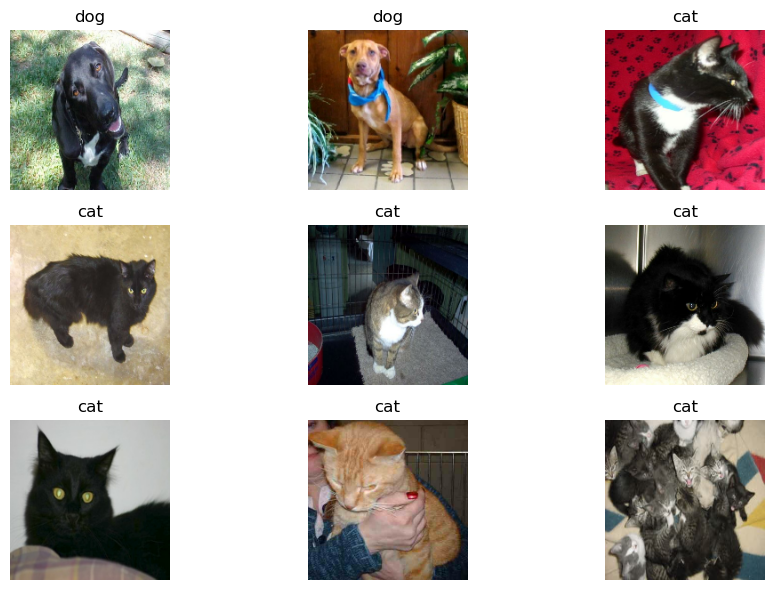

In [10]:
# Para ver si se han cargado bien las imagenes
plt.figure(figsize=(10, 6))           
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [8]:
#DEFINICION DE MI CNN

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.05, seed=SEED),
    ],
    name="data_augmentation",
)

model = keras.Sequential(
    [
        keras.Input(shape=(*IMAGE_SIZE, 3)),
        data_augmentation,
        layers.Rescaling(1.0 / 255),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="cnn_basica_cyd",
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "cnn_basica_cyd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 180, 180, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 90, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 90, 90, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 45, 45, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 45, 45, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 22, 22, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 22, 22, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 22, 22, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 11, 11, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 15488)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,965,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,206,273 (16.05 MB)

 Trainable params: 4,206,273 (16.05 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#Entrenamos con callbacks

CHECKPOINT_DIR = pathlib.Path("model_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "cnn_basica.keras"

callbacks = [
    keras.callbacks.EarlyStopping(           # para frenar el entrenamiento cuando la validacion deje de mejorar
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(              #para bajar la tasa de aprendizaje si la perdida se estanca
        monitor="val_loss", factor=0.5, patience=3, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(         # para guardar el mejor modelo
        filepath=CHECKPOINT_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    verbose=1,
)

history_df = pd.DataFrame(history.history)
history_df.tail()

Epoch 1/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.7051 - loss: 0.6999 
Epoch 1: val_accuracy improved from None to 0.68613, saving model to model_checkpoints\cnn_basica.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 15s 371ms/step - accuracy: 0.7302 - loss: 0.6300 - val_accuracy: 0.6861 - val_loss: 0.6389 - learning_rate: 0.0010
Epoch 2/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.7437 - loss: 0.5773 
Epoch 2: val_accuracy did not improve from 0.68613
35/35 ━━━━━━━━━━━━━━━━━━━━ 20s 359ms/step - accuracy: 0.7402 - loss: 0.5826 - val_accuracy: 0.6861 - val_loss: 0.6205 - learning_rate: 0.0010
Epoch 3/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.7365 - loss: 0.5773 
Epoch 3: val_accuracy did not improve from 0.68613
35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 360ms/step - accuracy: 0.7402 - loss: 0.5769 - val_accuracy: 0.6861 - val_loss: 0.6223 - learning_rate: 0.0010
Epoch 4/25
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.7474 - loss: 0.5609 
Epoch 4: val_accurac

,accuracy,loss,val_accuracy,val_loss,learning_rate
20,0.839562,0.354491,0.799270,0.416644,0.0005
21,0.833181,0.362575,0.802920,0.425179,0.0005
22,0.842297,0.350752,0.806569,0.422073,0.0005
23,0.855059,0.326853,0.817518,0.409065,0.0005
24,0.863263,0.303238,0.813869,0.447336,0.0005


Accuracy: 0.8175
Pérdida: 0.4091


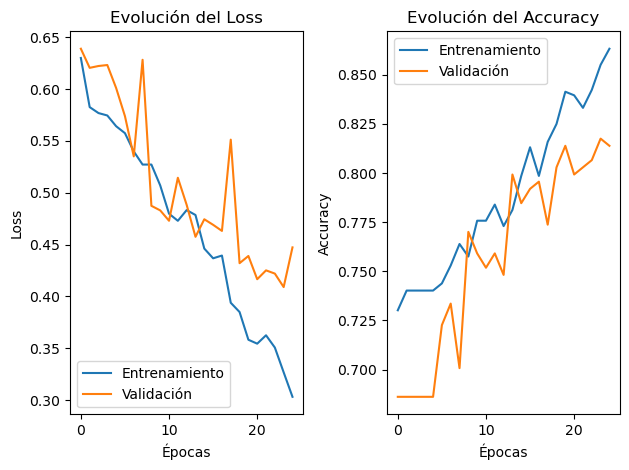

In [11]:
# evaluamos el analisis

best_model = keras.models.load_model(CHECKPOINT_PATH)
val_loss, val_acc = best_model.evaluate(val_ds, verbose=0)

print(f"Accuracy: {val_acc:.4f}")
print(f"Pérdida: {val_loss:.4f}")

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Evolución del Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Evolución del Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
-------------------------------------------------------------------------------------------------------------
MODELO TRANSFER LEARNING: MobileNetV2
-------------------------------------------------------------------------------------------------------------

In [12]:
# definicion del nuevo modelo de transfer learning usando MobileNet V2

preprocess_input = keras.applications.mobilenet_v2.preprocess_input

base_model = MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False 

inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="transfer_learning_input")
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3, seed=SEED)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

transfer_model = keras.Model(inputs, outputs, name="transfer_mobilenetv2")
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

transfer_model.summary()


C:\Users\tortu\AppData\Local\Temp\ipykernel_22436\3380011725.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "transfer_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ transfer_learning_input (InputLayer) │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 6, 6, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │           1,281 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
# Entrenamineto del modelo nuevo con callbacks

TRANSFER_CHECKPOINT_PATH = CHECKPOINT_DIR / "transfer_mobilenet.keras"          # esto crea una ruta dentro de donde ya guardaba los checkpoints para que se guarde la mejor version del nuevo modelo 

transfer_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(
        filepath=TRANSFER_CHECKPOINT_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=transfer_callbacks,
    verbose=1,
)


Epoch 1/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.7045 - loss: 0.6902 
Epoch 1: val_accuracy improved from None to 0.70438, saving model to model_checkpoints\transfer_mobilenet.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 552ms/step - accuracy: 0.7147 - loss: 0.6376 - val_accuracy: 0.7044 - val_loss: 0.5983
Epoch 2/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.7773 - loss: 0.5259 
Epoch 2: val_accuracy improved from 0.70438 to 0.77372, saving model to model_checkpoints\transfer_mobilenet.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 475ms/step - accuracy: 0.7748 - loss: 0.5106 - val_accuracy: 0.7737 - val_loss: 0.4715
Epoch 3/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.8021 - loss: 0.4282 
Epoch 3: val_accuracy improved from 0.77372 to 0.82117, saving model to model_checkpoints\transfer_mobilenet.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 387ms/step - accuracy: 0.8186 - loss: 0.4062 - val_accuracy: 0.8212 - val_loss: 0.3802
Epoch 4/15
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 35

Transfer Learning - Accuracy: 0.9672
Transfer Learning - Pérdida: 0.1251


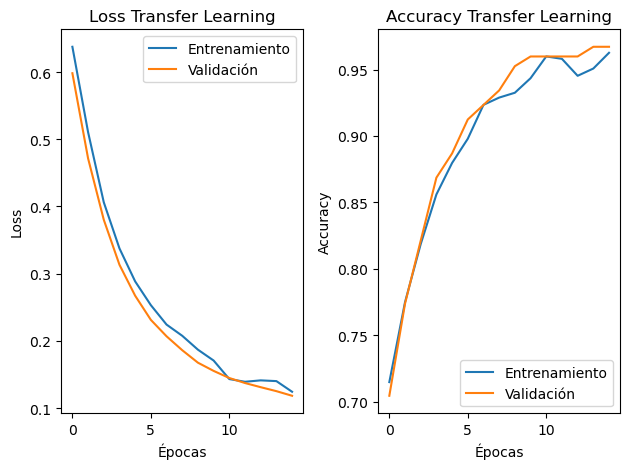

In [14]:
# evaluamos el analisis

best_transfer_model = keras.models.load_model(TRANSFER_CHECKPOINT_PATH)
transfer_val_loss, transfer_val_acc = best_transfer_model.evaluate(val_ds, verbose=0)

print(f"Transfer Learning - Accuracy: {transfer_val_acc:.4f}")
print(f"Transfer Learning - Pérdida: {transfer_val_loss:.4f}")

plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['loss'], label='Entrenamiento')
plt.plot(history_transfer.history['val_loss'], label='Validación')
plt.title('Loss Transfer Learning')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['accuracy'], label='Entrenamiento')
plt.plot(history_transfer.history['val_accuracy'], label='Validación')
plt.title('Accuracy Transfer Learning')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## Generación del CSV final de Predicciones

Una vez **definido y entrenado tu modelo** (no incluido en esta plantilla) y separadas tus imágenes de prueba en `X_test`, genera el archivo `predicciones_cats_dogs.csv` con el siguiente formato:

```text
id,label
0,0
1,0
2,1
...
```

Donde:
- `id` es el índice (comenzando en 0) de la imagen de prueba.
- `label` es `0` para gato y `1` para perro.

Notas importantes:
- Esta celda asume que tu **modelo** tiene una **salida sigmoide** (`Dense(1, activation='sigmoid')`) y que dispones de un `X_test` con las imágenes de evaluación (preprocesadas igual que X).
- Si usas una salida softmax de 2 neuronas, adapta la conversión de `y_pred` a clases.

In [ ]:
# Generación de CSV de predicciones
# Requisitos previos:
# - Debes haber definido y entrenado tu 'model'
# - Debes tener preparado 'X_test' con el mismo preprocesamiento (224x224, RGB, normalizado)

# Obtener predicciones del modelo
y_pred = model.predict(X_test, verbose=0)

# Si tu salida es sigmoide (1 neurona → binaria)
y_pred_classes = (y_pred > 0.5).astype("int32").flatten()

# Crear DataFrame con el formato solicitado
df = pd.DataFrame({
    "id": np.arange(1, len(y_pred_classes) + 1),
    "label": y_pred_classes
})

# Guardar como CSV
output_path = "predicciones_cats_dogs.csv"
df.to_csv(output_path, index=False)

print(f"Archivo guardado correctamente como: {output_path}")
df.head()